In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

In [ ]:
# @title Default title text
cola = ["fLength","fWidth","fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans", "fAlpha","fDist","class"]
df = pd.read_csv("magic04.data",names=cola)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["class"].unique()

array(['g', 'h'], dtype=object)

In [ ]:
df["class"] = (df["class"] == "g").astype(int)

In [ ]:
df["class"].unique()

array([1, 0])

In [ ]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


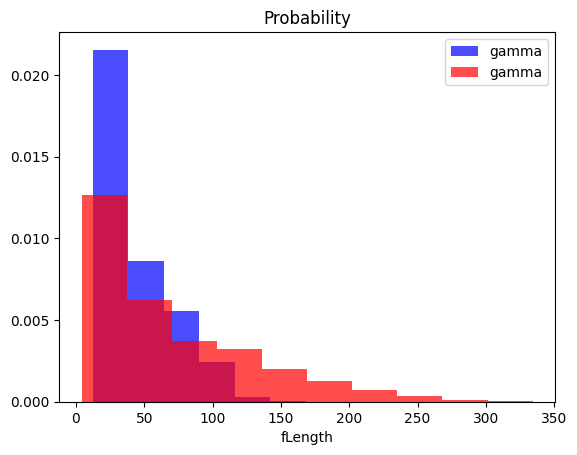

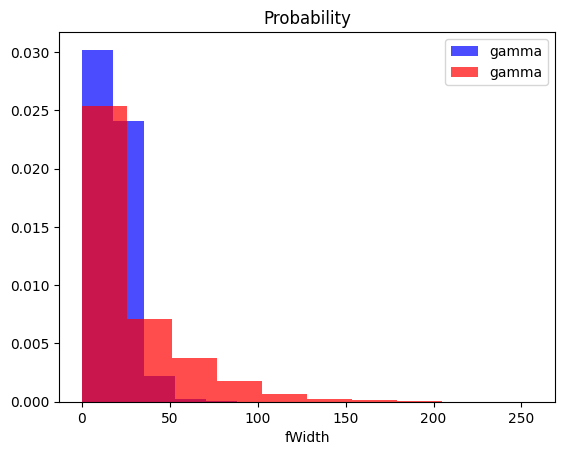

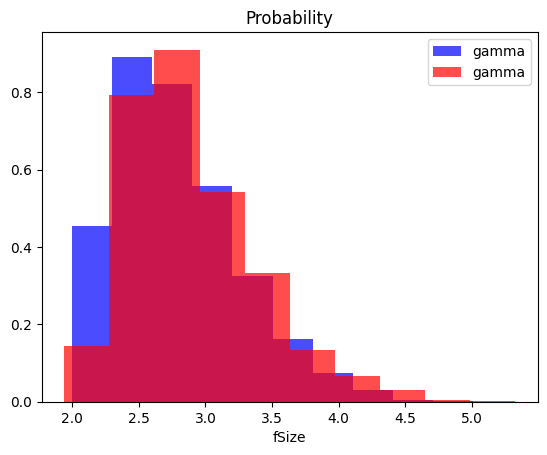

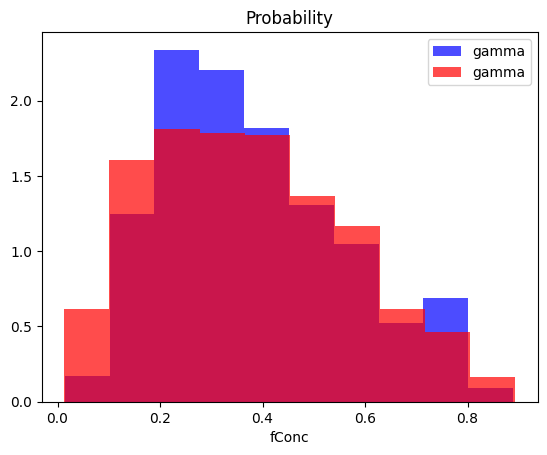

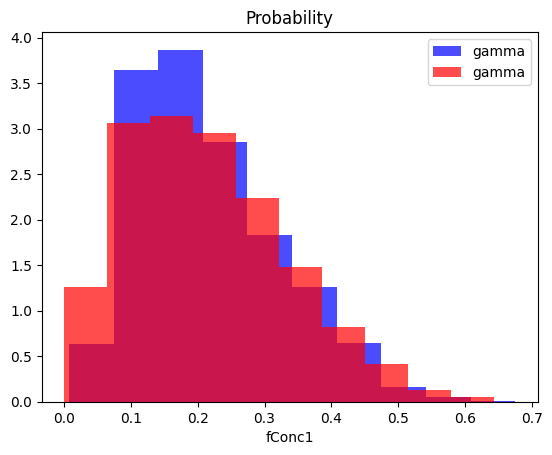

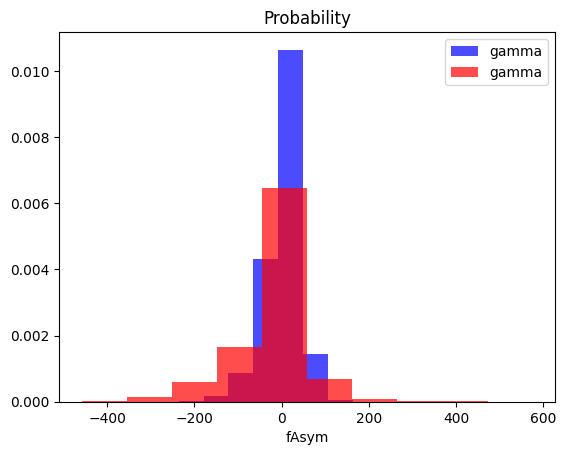

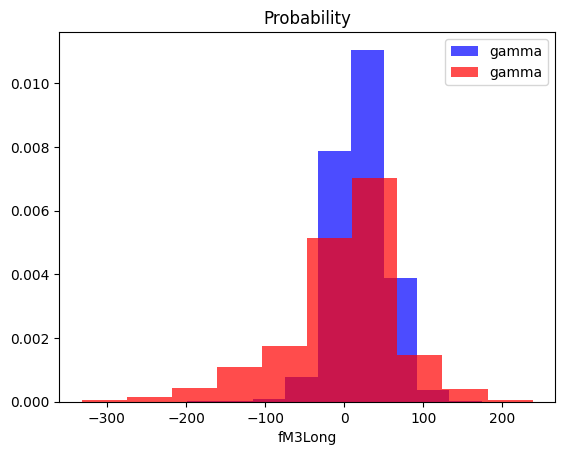

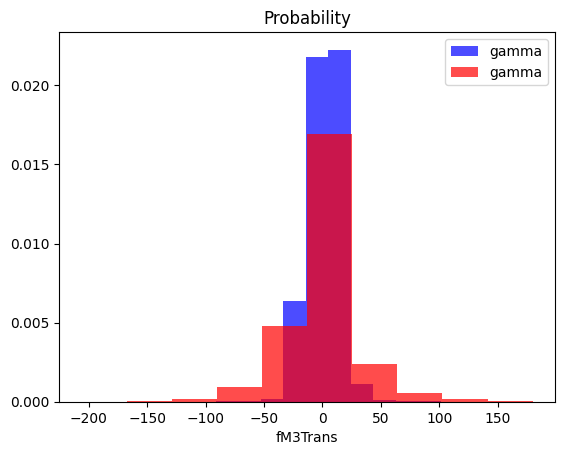

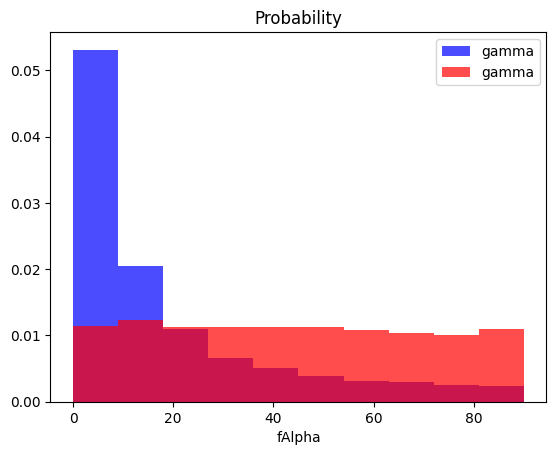

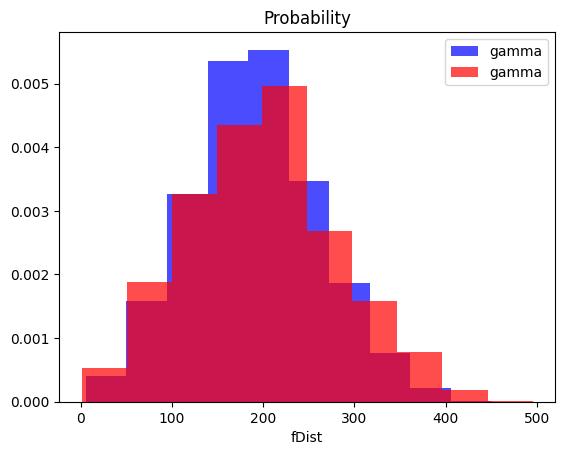

In [ ]:
for label in cola[:-1]:
  plt.hist(df[df["class"]==1][label], color= "blue", label="gamma",alpha=0.7,density=True)
  plt.hist(df[df["class"]==0][label], color= "red", label="gamma",alpha=0.7,density=True)
  plt.title("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

Train, validation, test dataset

In [ ]:
train, valid, test = np.split(df.sample(frac=1),[int(0.6*len(df)), int(0.8*len(df))])

In [ ]:
train, x_train, y_train = scale_dateset(train,oversample=True)

In [ ]:
len (x_train)

14842

In [ ]:
sum (x_train==1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
sum(y_train==0)

np.int64(7421)

In [ ]:
def scale_dataset (dataframe, oversample= False):
  x= dataframe[dataframe.columns[:-1]].values
  y= dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)


  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x,y)

  data = np.hstack((x,np.reshape(y,(-1,1))))

  return data, x, y

In [ ]:
train, temp = train_test_split(df, test_size=0.3, random_state=42)
valid, test = train_test_split(temp, test_size=0.5, random_state=42)

In [ ]:
train, x_train,y_train = scale_dataset(train,oversample = True)
valid, x_valid, y_valid = scale_dataset(valid, oversample=False)
test, x_test, y_test = scale_dataset(test, oversample=False)


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn_model.predict(x_test)

In [ ]:
y_pred

array([0, 1, 1, ..., 1, 1, 1])

In [ ]:
y_test

array([0, 1, 0, ..., 1, 1, 1])

In [ ]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1007
           1       0.86      0.86      0.86      1846

    accuracy                           0.81      2853
   macro avg       0.80      0.80      0.80      2853
weighted avg       0.81      0.81      0.81      2853



In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(x_train, y_train)

In [ ]:
y_pred = nb_model.predict(x_test)

In [ ]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.38      0.50      1007
           1       0.73      0.92      0.81      1846

    accuracy                           0.73      2853
   macro avg       0.73      0.65      0.66      2853
weighted avg       0.73      0.73      0.70      2853



**logictic regation**

In [58]:
from sklearn.linear_model import LogisticRegression

In [61]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train,y_train)

In [64]:
y_pred = lg_model.predict(x_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.72      0.72      1007
           1       0.85      0.84      0.84      1846

    accuracy                           0.80      2853
   macro avg       0.78      0.78      0.78      2853
weighted avg       0.80      0.80      0.80      2853



In [65]:
from sklearn.svm import SVC

In [67]:
svm_model = SVC()
svm_model = svm_model.fit(x_train,y_train)

In [68]:
y_pred = svm_model.predict(x_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1007
           1       0.90      0.90      0.90      1846

    accuracy                           0.87      2853
   macro avg       0.86      0.86      0.86      2853
weighted avg       0.87      0.87      0.87      2853

